
# Machine Learning Approach to Network Intrusion Detection for IoT Devices  
**My individual contribution:** Outlier-based intrusion detection on **NSL-KDD** using **Isolation Forest**, **DBSCAN**, and **Local Outlier Factor (LOF)**.



## 1. Environment setup (libraries and imports)


In [1]:

!pip -q install scikit-learn pandas numpy matplotlib seaborn

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA

sns.set_style("whitegrid")
print("Environment ready.")


Environment ready.



## 2. Dataset acquisition and loading


In [2]:

!wget -q https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt -O KDDTrain+.txt

cols = ["duration","protocol_type","service","flag","src_bytes","dst_bytes","land","wrong_fragment","urgent",
        "hot","num_failed_logins","logged_in","num_compromised","root_shell","su_attempted","num_root",
        "num_file_creations","num_shells","num_access_files","num_outbound_cmds","is_host_login","is_guest_login",
        "count","srv_count","serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate","same_srv_rate",
        "diff_srv_rate","srv_diff_host_rate","dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
        "dst_host_diff_srv_rate","dst_host_same_src_port_rate","dst_host_srv_diff_host_rate",
        "dst_host_serror_rate","dst_host_srv_serror_rate","dst_host_rerror_rate","dst_host_srv_rerror_rate",
        "label","difficulty"]

df = pd.read_csv("KDDTrain+.txt", names=cols)
print("Dataset loaded:", df.shape)
df.head(3)


Dataset loaded: (125973, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.0,0.0,0.0,0.05,0.0,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.0,0.0,0.0,0.00,0.0,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.0,1.0,1.0,0.00,0.0,neptune,19



## 3. Data preprocessing


In [3]:

df["attack"] = (df["label"] != "normal").astype(int)
for c in ["protocol_type","service","flag"]:
    df[c] = LabelEncoder().fit_transform(df[c])
df = df.drop(columns=["label","difficulty"])

scaler = StandardScaler()
X = scaler.fit_transform(df.drop(columns=["attack"]))
y = df["attack"].values
print(f"Processed shape: {X.shape}, Attack ratio: {y.mean():.3f}")


Processed shape: (125973, 41), Attack ratio: 0.465



## 4. Train–test split and avoiding bias


In [4]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
print("Training set:", X_train.shape, "| Testing set:", X_test.shape)


Training set: (88181, 41) | Testing set: (37792, 41)



## 5. Evaluation setup


In [5]:

def evaluate_with_percentile(y_true, scores, top_percent=5):
    thr = np.percentile(scores, 100 - top_percent)
    y_pred = (scores >= thr).astype(int)
    auc = roc_auc_score(y_true, scores)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)
    return {"AUC":auc, "Precision":prec, "Recall":rec, "F1":f1, "CM":cm, "thr":thr}



## 6. Isolation Forest — PCA(2D) and runtime


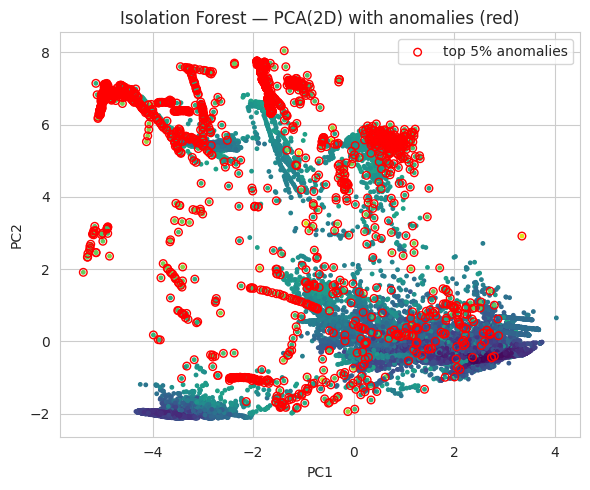

Isolation Forest: {'AUC': np.float64(0.7269503442216262), 'Precision': 0.7592592592592593, 'Recall': 0.08158508158508158, 'F1': 0.14733815904307201, 'thr': np.float64(0.0008464356215530569), 'Model': 'Isolation Forest', 'Time (s)': 1.985}


In [6]:

start = time.time()

iso = IsolationForest(n_estimators=200, max_samples='auto', contamination=0.05, random_state=42)
iso.fit(X_train)
scores_if = -iso.decision_function(X_test)

runtime_if = time.time() - start

res_if = evaluate_with_percentile(y_test, scores_if, top_percent=5)
res_if["Model"] = "Isolation Forest"
res_if["Time (s)"] = round(runtime_if, 3)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_test)
thr_if = np.percentile(scores_if, 95)
out_if = scores_if >= thr_if

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=scores_if, s=6, cmap="viridis")
plt.scatter(X2[out_if,0], X2[out_if,1], facecolors='none', edgecolors='r', s=30, label='top 5% anomalies')
plt.title("Isolation Forest — PCA(2D) with anomalies (red)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.tight_layout(); plt.show()

print("Isolation Forest:", {k: v for k, v in res_if.items() if k != "CM"})



## 7. DBSCAN — PCA(2D) core/border/noise and runtime


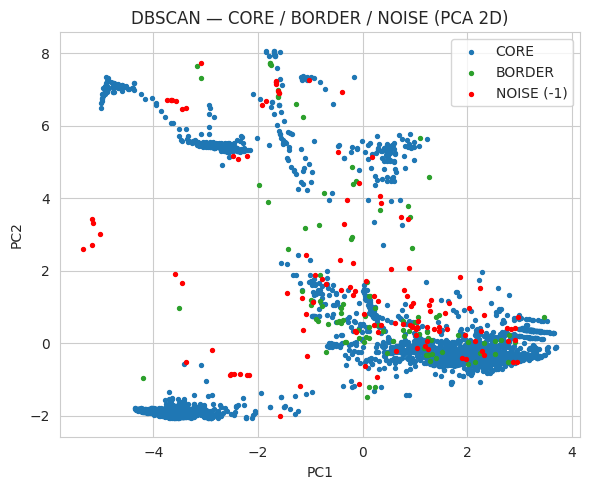

Counts → CORE: 4774 | BORDER: 101 | NOISE: 125
DBSCAN: {'AUC': np.float64(0.5005230852825369), 'Precision': 0.4616, 'Recall': 1.0, 'F1': 0.6316365626710454, 'thr': np.float64(0.0), 'Model': 'DBSCAN', 'Time (s)': 0.485}


In [7]:

subset = 5000
X_db, y_db = X_test[:subset], y_test[:subset]

start = time.time()
k = 10
db = DBSCAN(eps=3, min_samples=k)
db.fit(X_db)
runtime_db = time.time() - start

labels = db.labels_
core_mask = np.zeros_like(labels, dtype=bool)
if hasattr(db, "core_sample_indices_"):
    core_mask[db.core_sample_indices_] = True
border_mask = (labels != -1) & (~core_mask)
noise_mask  = (labels == -1)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_db)
plt.figure(figsize=(6,5))
plt.scatter(X2[core_mask,0],   X2[core_mask,1],   s=8, c='tab:blue',  label='CORE')
plt.scatter(X2[border_mask,0], X2[border_mask,1], s=8, c='tab:green', label='BORDER')
plt.scatter(X2[noise_mask,0],  X2[noise_mask,1],  s=8, c='red',       label='NOISE (-1)')
plt.title("DBSCAN — CORE / BORDER / NOISE (PCA 2D)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.tight_layout(); plt.show()

scores_db = np.where(labels == -1, 1.0, 0.0)
res_db = evaluate_with_percentile(y_db, scores_db, top_percent=5)
res_db["Model"] = "DBSCAN"
res_db["Time (s)"] = round(runtime_db, 3)

print(f"Counts → CORE: {core_mask.sum()} | BORDER: {border_mask.sum()} | NOISE: {noise_mask.sum()}")
print("DBSCAN:", {k: v for k, v in res_db.items() if k != "CM"})



## 8. LOF — PCA(2D) and runtime


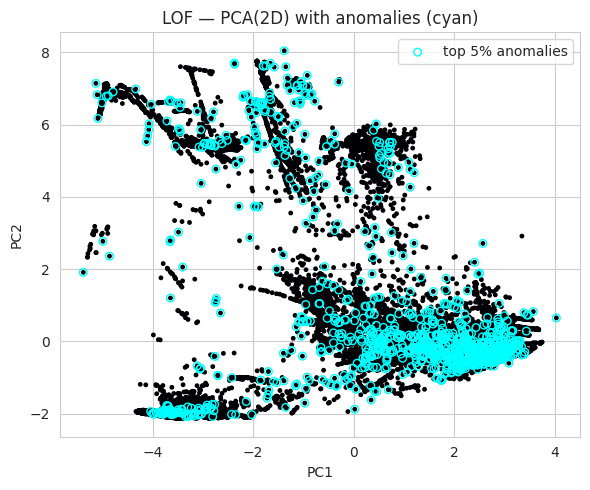

LOF: {'AUC': np.float64(0.4521309473526181), 'Precision': 0.2074074074074074, 'Recall': 0.022286656432997896, 'F1': 0.04024847271420504, 'thr': np.float64(0.0371612918453583), 'Model': 'Local Outlier Factor', 'Time (s)': 111.417}


In [8]:

start = time.time()

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05, novelty=True)
lof.fit(X_train)
scores_lof = -lof.decision_function(X_test)

runtime_lof = time.time() - start

res_lof = evaluate_with_percentile(y_test, scores_lof, top_percent=5)
res_lof["Model"] = "Local Outlier Factor"
res_lof["Time (s)"] = round(runtime_lof, 3)

pca = PCA(n_components=2, random_state=42)
X2 = pca.fit_transform(X_test)
thr_lof = np.percentile(scores_lof, 95)
out_lof = scores_lof >= thr_lof

plt.figure(figsize=(6,5))
plt.scatter(X2[:,0], X2[:,1], c=scores_lof, s=6, cmap="magma")
plt.scatter(X2[out_lof,0], X2[out_lof,1], facecolors='none', edgecolors='cyan', s=30, label='top 5% anomalies')
plt.title("LOF — PCA(2D) with anomalies (cyan)")
plt.xlabel("PC1"); plt.ylabel("PC2"); plt.legend()
plt.tight_layout(); plt.show()

print("LOF:", {k: v for k, v in res_lof.items() if k != "CM"})



## 9. Comprehensive comparison (with accurate runtime)


Combined results:


,Model,AUC,Precision,Recall,F1,Time (s)
0,Isolation Forest,0.726950,0.759259,0.081585,0.147338,1.985
1,DBSCAN,0.500523,0.461600,1.000000,0.631637,0.485
2,Local Outlier Factor,0.452131,0.207407,0.022287,0.040248,111.417


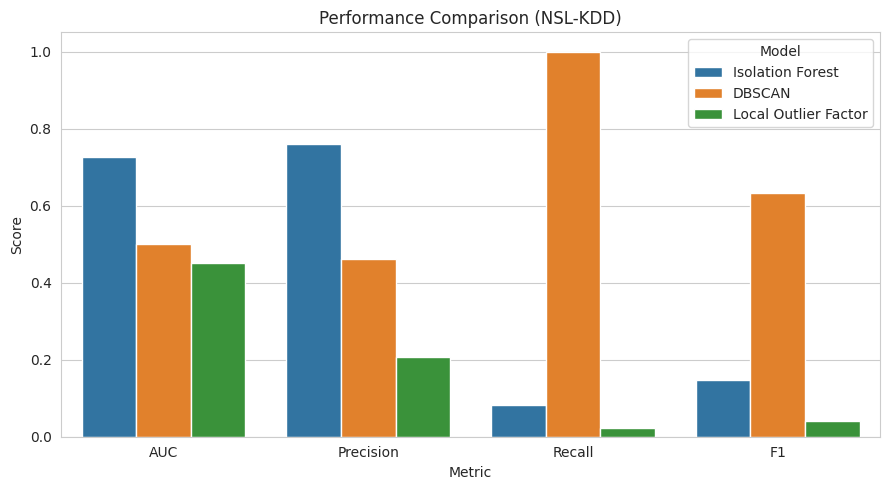

/tmp/ipython-input-527995409.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=results, x="Model", y="Time (s)", palette="pastel")


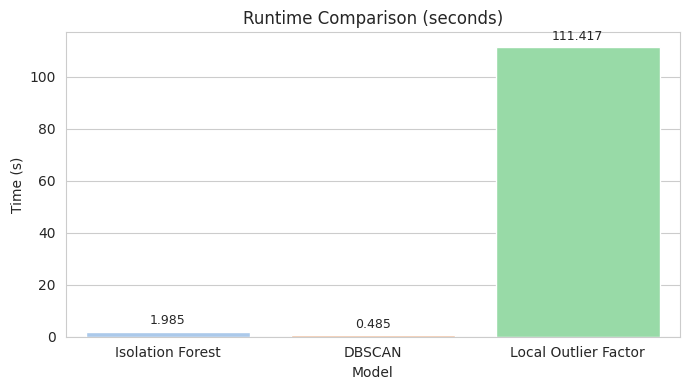

In [9]:

results = pd.DataFrame([
    {"Model": res_if["Model"],  "AUC": res_if["AUC"],  "Precision": res_if["Precision"],
     "Recall": res_if["Recall"], "F1": res_if["F1"], "Time (s)": res_if["Time (s)"]},
    {"Model": res_db["Model"],  "AUC": res_db["AUC"],  "Precision": res_db["Precision"],
     "Recall": res_db["Recall"], "F1": res_db["F1"], "Time (s)": res_db["Time (s)"]},
    {"Model": res_lof["Model"], "AUC": res_lof["AUC"], "Precision": res_lof["Precision"],
     "Recall": res_lof["Recall"], "F1": res_lof["F1"], "Time (s)": res_lof["Time (s)"]},
])
print("Combined results:")
display(results)

melted = results.melt(id_vars=["Model","Time (s)"], var_name="Metric", value_name="Score")
plt.figure(figsize=(9,5))
sns.barplot(data=melted, x="Metric", y="Score", hue="Model")
plt.title("Performance Comparison (NSL-KDD)")
plt.ylabel("Score")
plt.tight_layout(); plt.show()

plt.figure(figsize=(7,4))
ax = sns.barplot(data=results, x="Model", y="Time (s)", palette="pastel")
plt.title("Runtime Comparison (seconds)")
plt.ylabel("Time (s)")
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f"{height:.3f}",
                (p.get_x() + p.get_width()/2., height),
                ha='center', va='bottom', fontsize=9, xytext=(0,3), textcoords='offset points')
plt.tight_layout(); plt.show()
